# 05 Model ARIMAX - Rolling Backtest 24h (Monthly Refit)

## Scope
- Fit once before 2025 starts.
- Forecast next 24h each day in 2025.
- Append each day's actuals to model state (`refit=False`).
- Refit full parameters at month boundaries (`_retrainM`).

This is a speed/realism compromise versus daily full refit.

## Implementation Comment
This notebook implements the practical compromise for ARIMAX/SARIMAX runtime:
- Fit once before `2025-01-01`.
- During 2025, forecast next 24 hours each day.
- After each day, update model state with realized actuals via `append(..., refit=False)`.
- Refit full model parameters at each month boundary.

## For your case, use this schedule
1. Fit ARIMAX/SARIMAX once on data up to `2024-12-31 23:00`.
2. For each day in 2025:
   - Forecast next 24 hours (`h=24`) using that day?s exogenous inputs.
   - When actual prices for that day are available, append/update state (no full refit).
3. Do a full refit at month boundaries (for example, `2025-02-01`, `2025-03-01`, ...).

### How January is computed (monthly refit plan)
- `2025-01-01` forecast: from model fitted on history through end of 2024.
- After Jan 1 actuals arrive, append those 24 actuals.
- `2025-01-02` forecast: same parameters, updated state (includes Jan 1 actuals).
- Repeat daily through `2025-01-31`.
- No full parameter re-estimation during January.

### How February is computed
- At start of `2025-02-01`, do full refit using all data through `2025-01-31 23:00`.
- Forecast `2025-02-01` 24h with new parameters plus Feb 1 exogenous values.
- After Feb 1 actuals arrive, append/update state.
- Continue daily (`2025-02-02`, `2025-02-03`, ...) with same February parameters.
- Next full refit at `2025-03-01`.


In [1]:
# Setup
# If needed:
# %pip install statsmodels scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA


In [2]:
# Config
DATA_PATH = '../../data_cleaned/merged/02_4_clean_data.csv'
H = 24
MAX_CYCLES = None   # e.g. 60 for fast debugging

start_date = pd.Timestamp('2019-01-01 00:00:00')
split_date = pd.Timestamp('2025-01-01 00:00:00')
end_date = pd.Timestamp('2026-01-01 00:00:00')

# Load data
df = pd.read_csv(DATA_PATH)
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'], errors='coerce', utc=True).dt.tz_localize(None)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df[(df['date'] >= start_date) & (df['date'] < end_date)].copy()
df = pd.get_dummies(df, columns=['year'], drop_first=True)
df = df.rename(columns={'period_start_utc': 'ds', 'price': 'y'}).sort_values('ds').reset_index(drop=True)

base_exog = [
    'load_forecast_da', 'res_sum_da', 'gen_forecast_da',
    'dayofyear_sin1', 'dayofyear_cos1',
    'hour_sin1', 'hour_cos1',
    'dayofweek_sin1', 'dayofweek_cos1',
    'is_holiday', 'price_gas'
]
year_dummies = [c for c in df.columns if c.startswith('year_')]
exog_cols = base_exog + year_dummies
model_df = df[['ds', 'y'] + exog_cols].copy()

cutoffs = pd.date_range(start=split_date, end=end_date - pd.Timedelta(days=1), freq='D')
if MAX_CYCLES is not None:
    cutoffs = cutoffs[:MAX_CYCLES]

print(f'Rows: {len(model_df):,} | Cycles: {len(cutoffs)}')

ORDER = (1, 0, 1)


Rows: 61,367 | Cycles: 365


In [3]:
# Initial fit on history before test period
train0 = model_df[model_df['ds'] < split_date]
res = ARIMA(endog=train0['y'], exog=train0[exog_cols].astype(float), order=ORDER).fit()
current_month = split_date.to_period('M')
print('Initial fit done')


Initial fit done


In [4]:
# Rolling daily forecast with monthly full refit + daily state append
rows = []
failed = 0

for i, cutoff in enumerate(cutoffs, 1):
    cutoff_month = cutoff.to_period('M')

    # Refit at first day of each new month using all history up to cutoff
    if cutoff_month != current_month:
        train_hist = model_df[model_df['ds'] < cutoff]
        res = ARIMA(endog=train_hist['y'], exog=train_hist[exog_cols].astype(float), order=ORDER).fit()
        current_month = cutoff_month

    test_h = model_df[(model_df['ds'] >= cutoff) & (model_df['ds'] < cutoff + pd.Timedelta(hours=H))].copy()
    if len(test_h) != H:
        continue

    try:
        pred = res.forecast(steps=H, exog=test_h[exog_cols].astype(float))
        out = test_h[['ds', 'y']].copy()
        out['prediction'] = np.asarray(pred)
        out['cutoff'] = cutoff
        rows.append(out)

        # Update state with realized data, no parameter refit
        res = res.append(endog=test_h['y'], exog=test_h[exog_cols].astype(float), refit=False)
    except Exception:
        failed += 1

    if i % 30 == 0:
        print(f'Processed {i}/{len(cutoffs)} | failed={failed}')

results = pd.concat(rows, ignore_index=True).rename(columns={'y': 'actual'})
print(f'Completed cycles: {results.cutoff.nunique()} | Failed cycles: {failed}')
results.head()


Processed 30/365 | failed=0
Processed 60/365 | failed=0
Processed 90/365 | failed=0
Processed 120/365 | failed=0


c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Processed 150/365 | failed=0
Processed 180/365 | failed=0
Processed 210/365 | failed=0


c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Processed 240/365 | failed=0
Processed 270/365 | failed=0


c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Processed 300/365 | failed=0
Processed 330/365 | failed=0
Processed 360/365 | failed=0
Completed cycles: 364 | Failed cycles: 0


,ds,actual,prediction,cutoff
0,2025-01-01 00:00:00,1.60,-41.870123,2025-01-01
1,2025-01-01 01:00:00,0.00,-47.093038,2025-01-01
2,2025-01-01 02:00:00,-0.01,-48.181191,2025-01-01
3,2025-01-01 03:00:00,-0.01,-49.711322,2025-01-01
4,2025-01-01 04:00:00,-0.06,-49.849658,2025-01-01


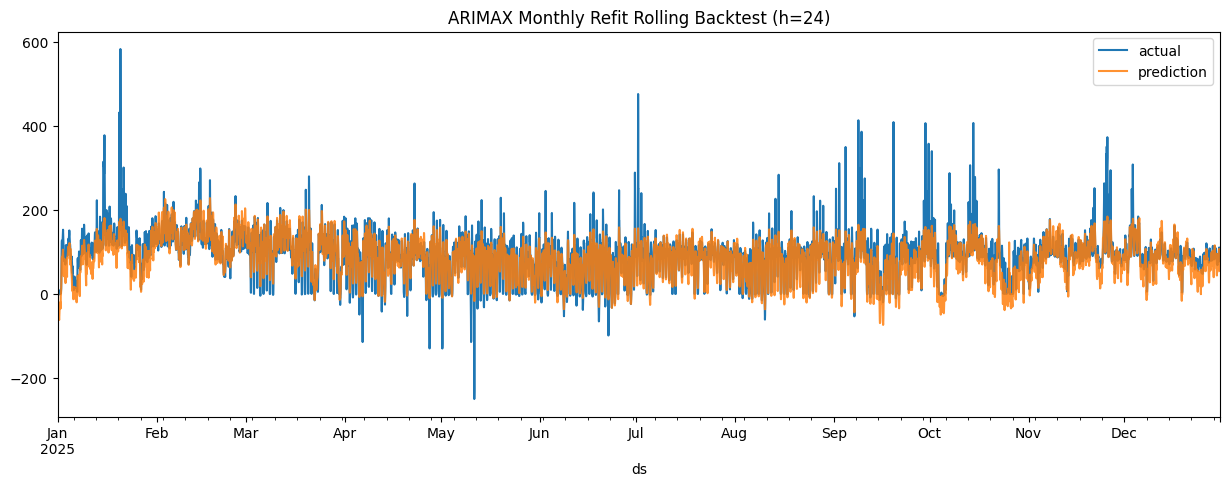

In [5]:
# Plot
plot_df = results.set_index('ds').sort_index()
ax = plot_df[['actual']].plot(figsize=(15, 5), title='ARIMAX Monthly Refit Rolling Backtest (h=24)')
plot_df['prediction'].plot(ax=ax, alpha=0.85)
ax.legend(['actual', 'prediction'])
plt.show()


In [6]:
# Unified metrics + export for comparison
rmse = mean_squared_error(results['actual'], results['prediction'], squared=False)
mae = mean_absolute_error(results['actual'], results['prediction'])
smape = 100 * np.mean(
    2 * np.abs(results['actual'] - results['prediction']) /
    (np.abs(results['actual']) + np.abs(results['prediction']) + 1e-8)
)
mask = np.abs(results['actual']) >= 10
mape_filtered = (
    np.mean(np.abs((results.loc[mask, 'actual'] - results.loc[mask, 'prediction']) /
                   np.abs(results.loc[mask, 'actual']))) * 100
    if mask.any() else np.nan
)

print(f'RMSE: {rmse:,.4f}')
print(f'MAE:  {mae:,.4f}')
print(f'sMAPE: {smape:,.2f}%')
print(f'MAPE (|actual|>=10): {mape_filtered:,.2f}%')

out_dir = Path('../../artifacts/model_results')
out_dir.mkdir(parents=True, exist_ok=True)
metrics_df = pd.DataFrame([{
    'model': 'ARIMAX_retrainM',
    'rmse': rmse,
    'mae': mae,
    'smape': smape,
    'mape_filtered_abs_ge_10': mape_filtered,
    'n_predictions': len(results)
}])

metrics_df.to_csv(out_dir / 'arimax_retrainm_metrics_rolling_24h.csv', index=False)
results.to_csv(out_dir / 'arimax_retrainm_predictions_rolling_24h.csv', index=False)
metrics_df


RMSE: 27.5033
MAE:  18.4627
sMAPE: 39.47%
MAPE (|actual|>=10): 22.43%


,model,rmse,mae,smape,mape_filtered_abs_ge_10,n_predictions
0,ARIMAX_retrainM,27.503259,18.462715,39.470008,22.426967,8736
